### This notebook is intended to produce the plots and results shown in tables and plots across the paper with respect to four particular problem instances with different hardness parameter

In [1]:
### imports
from scipy.stats import bootstrap

import sys
sys.path.append('../../')
from fixup.fixup import remove_with_check, remove_by_participation, remove_by_participation_descending, remove_first, remove_with_check_and_add, get_fixup_sol

import json 
import os 
from collections import Counter 
import numpy as np 
import matplotlib.pyplot as plt 
import networkx as nx 

### utils

def a_stat(true_mis, num_sols): # the probability of MIS
    def p_mis(x):
        return sum([1 for i in x if i==true_mis])/num_sols
    return p_mis

def graph_from_atom_positions(atom_positions): 
    node_labels = range(len(atom_positions))

    edge_dict = {}
    for i in range(len(atom_positions)):
        x, y = atom_positions[i]
        edge_dict[node_labels[i]] = []
        for j in range(i+1,len(atom_positions)):
            u, v = atom_positions[j]
            if abs(x-u) <= 1 and abs(y-v) <=1:
                edge_dict[node_labels[i]] += [node_labels[j]]

    G = nx.from_dict_of_lists(edge_dict)
    return G

def clean_form_counts(counts): 
    
    unique_sols = set(tuple(i['nodes']) for i in counts)
    all_counts=[]

    for sol in unique_sols:
        result_counts = {}
        result_counts['nodes']=list(sol)
        result_counts['count']= sum([elem['count'] for elem in counts if elem['nodes']==list(sol)])
        all_counts.append(result_counts)
        
    return all_counts

In [2]:
## the ground true MIS for the problem instances

baseline = {
    "atoms_BMW2023_HP1435" : 45,
    "atoms_BMW2023_HP125" : 46, 
    "atoms_BMW2023_HP14.12" : 47,
    "atoms_BMW2023_HP1.478" : 45}

---------
problem atoms_BMW2023_HP1435 for qReduMIS with criteria inset: PMIS=  1.0 0.0


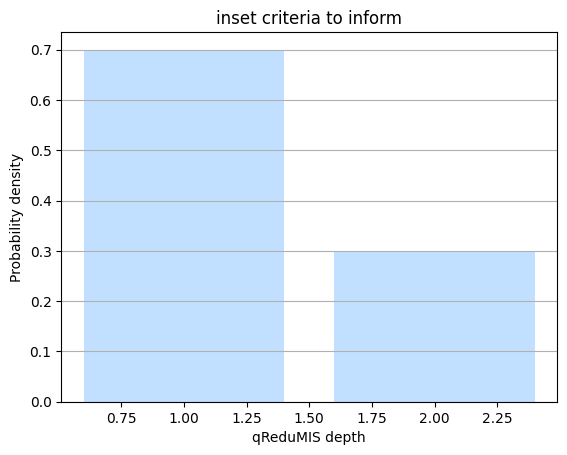

---------
problem atoms_BMW2023_HP1435 for QAA: PMIS=  0.0 0.0


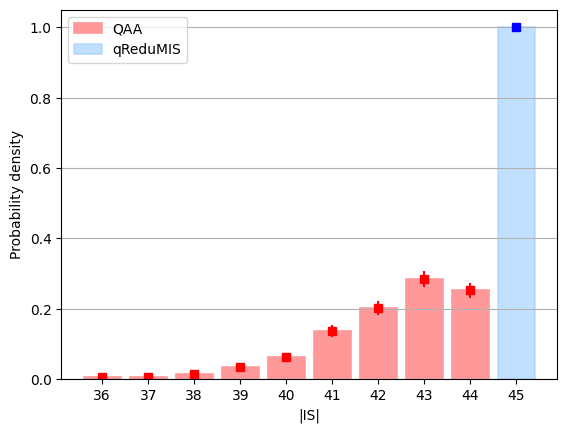

---------
problem atoms_BMW2023_HP125 for qReduMIS with criteria inset: PMIS=  1.0 0.0


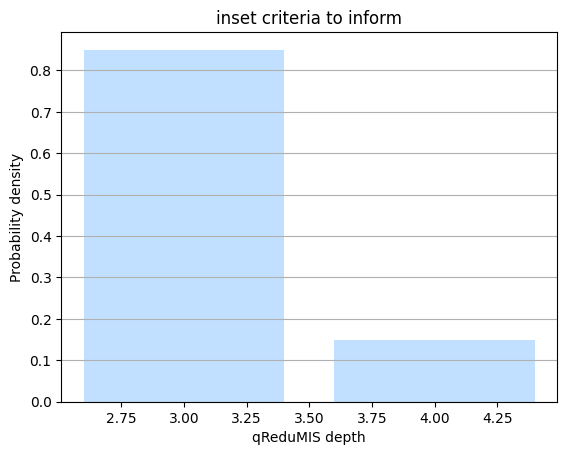

---------
problem atoms_BMW2023_HP125 for QAA: PMIS=  0.007 0.004


/tmp/ipykernel_17365/1119468014.py:99: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  res = bootstrap(data, stat, confidence_level=0.9)


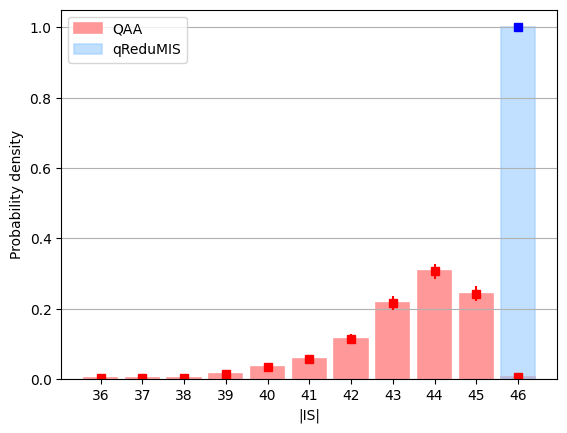

In [3]:
numshots=20
problems=["atoms_BMW2023_HP1435", "atoms_BMW2023_HP125"]
criteria="inset"

directory_path_qReduMIS=f"raw_results/qReduMIS/qReduMIS_table_hardware/{criteria}"
directory_path_QAA="raw_results/QAA/QAA_hardware"
date="Jan-16"
for problem in problems:
    sols=[]
    c_shots=[]
    for cshot in range(numshots):
        file_path=f"{directory_path_qReduMIS}/{problem}_componentsFalse_results_qReduMIS_cshot{cshot}.json"
        with open(file_path, "r") as infile:
            res = json.load(infile)
        sol=len(res['final']['sol'])
        sols.append(sol)
        num_its=res['final']['num iterations']
        c_shots.append(num_its)

    data = (sols,)
    counter=Counter(sols)
    values = list(counter.values())
    total = sum(values)
    probabilities = [val / total for val in values]

    true_mis=baseline[problem]
    stat=a_stat(true_mis, len(sols))
    res_boot = bootstrap(data, stat, confidence_level=0.9)

    print("---------")
    print(f"problem {problem} for qReduMIS with criteria {criteria}: PMIS= ", np.round(np.mean(res_boot.bootstrap_distribution),3),  np.round(np.std(res_boot.bootstrap_distribution),3))
    
    ### The distribution of qReduMIS depth or classical iterations among the classical shots         
    counter_c_shots=Counter(c_shots)
    values_c_shots = list(counter_c_shots.values())
    total_c_shots = sum(values_c_shots)
    probabilities_c_shots = [val / total_c_shots for val in values_c_shots]
    # Plot the distribution
    pastel_blue = (0.6, 0.8, 1.0)
    plt.bar(counter_c_shots.keys(), probabilities_c_shots, color=pastel_blue,  alpha=0.6)
    plt.xlabel("qReduMIS depth")
    plt.ylabel("Probability density")
    #plt.xticks([2, 3])
    plt.title(f"{criteria} criteria to inform")
    plt.grid(axis='y')
    plt.show()

    ### Comparison to QAA on hardware with postprocessing
    with open(f"{directory_path_QAA}/{problem}/{date}/results_postprocessed.json", "r") as infile:
        res = json.load(infile)

    all_counts=res['postprocessed_sols']

    ## we take the position of the atoms to get the edges 
    with open(f"testbed_instances/table_instances/{problem}.json", "r") as infile:
        atom_positions_init = json.load(infile)
    graph = graph_from_atom_positions(atom_positions_init)
    edges_list=list(graph.edges())
    all_sols_clean=clean_form_counts(all_counts)
    clean_solutions =get_fixup_sol(all_sols_clean, edges_list, remove_with_check_and_add)
    
    sols_QAA=[len(n['nodes']) for n in clean_solutions]
    counter_QAA=Counter(sols_QAA)
    values_QAA = list(counter_QAA.values())
    total_QAA = sum(values_QAA)
    probabilities_QAA = [val / total_QAA for val in values_QAA]

    data = (sols_QAA,)
    stat=a_stat(true_mis, len(sols_QAA))
    res_boot = bootstrap(data, stat, confidence_level=0.9)
    print("---------")
    print(f"problem {problem} for QAA: PMIS= ", np.round(np.mean(res_boot.bootstrap_distribution),3),  np.round(np.std(res_boot.bootstrap_distribution),3))
    

    # Plot the distribution
    pastel_red = (1.0, 0.6, 0.6)
    pastel_blue = (0.6, 0.8, 1.0)

    plt.bar(counter_QAA.keys(), probabilities_QAA, color=pastel_red, edgecolor=pastel_red, label="QAA", linewidth=1.2)
    # Add error bars
    bin_centers=counter_QAA.keys()
    errors=[]
    data=(sols_QAA,)
    for mis_size in bin_centers:
        stat = a_stat(mis_size, len(sols_QAA))
        res = bootstrap(data, stat, confidence_level=0.9)
        errors.append(np.std(res.bootstrap_distribution))

    plt.errorbar(bin_centers, probabilities_QAA, yerr=errors, fmt='s', color='red')

    ## qReduMIS
    plt.bar(counter.keys(), probabilities, color=pastel_blue, edgecolor=pastel_blue, label="qReduMIS", linewidth=1.2, alpha=0.6)
    # Add error bars
    bin_centers=counter.keys()
    errors=[]
    data=(sols,)
    for mis_size in bin_centers:
        stat = a_stat(mis_size, len(sols_QAA))
        res = bootstrap(data, stat, confidence_level=0.9)
        errors.append(np.std(res.bootstrap_distribution))

    plt.errorbar(bin_centers, probabilities, yerr=errors, fmt='s', color='blue')


    plt.xlabel("|IS|")
    plt.ylabel("Probability density")
    if problem=="atoms_BMW2023_HP1435":
        plt.xticks([36, 37, 38, 39, 40, 41, 42, 43, 44, 45])
    if problem=="atoms_BMW2023_HP125":
        #plt.xlim([33, 45.5])
        plt.xticks([36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46])
    plt.legend()        
    plt.grid(axis='y')
    #plt.savefig(f'distribution_IS_hardware_{problem}.png', dpi=300, bbox_inches='tight', transparent=False)
    plt.show()


        

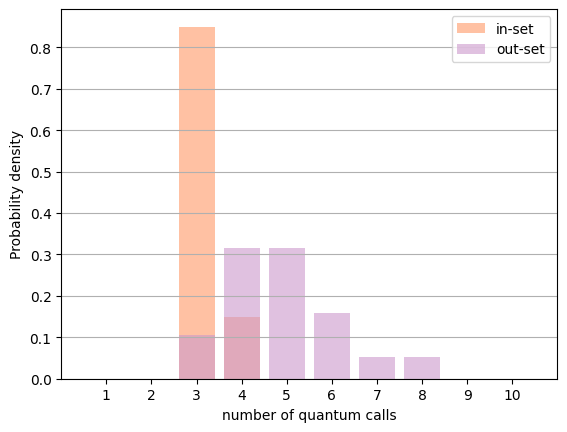

In [4]:
numshots=20
problem="atoms_BMW2023_HP125" 


## for the inset criteria
criteria="inset"
directory_path=f"raw_results/qReduMIS/qReduMIS_table_hardware/{criteria}"

sols_inset=[]
c_shots_inset=[]

for cshot in range(numshots):
    with open(f"{directory_path}/{problem}_componentsFalse_results_qReduMIS_cshot{cshot}.json", "r") as infile:
        res = json.load(infile)
    num_its=res['final']['num iterations']
    sol=len(res['final']['sol'])
    sols_inset.append(sol)
    c_shots_inset.append(num_its)

counter_c_shots_inset=Counter(c_shots_inset)
values_c_shots_inset = list(counter_c_shots_inset.values())
total_c_shots_inset = sum(values_c_shots_inset)
probabilities_c_shots_inset = [val / total_c_shots_inset for val in values_c_shots_inset]

## for the outset criteria
criteria="outset"
directory_path=f"raw_results/qReduMIS/qReduMIS_table_hardware/{criteria}"
sols_outset=[]
c_shots_outset=[]
for cshot in range(numshots):
    with open(f"{directory_path}/{problem}_componentsFalse_results_qReduMIS_cshot{cshot}.json", "r") as infile:
        res = json.load(infile)
    if 'final' in res.keys():
        num_its=res['final']['num iterations']
        sol=len(res['final']['sol'])


        sols_outset.append(sol)
        c_shots_outset.append(num_its)

counter_c_shots_outset=Counter(c_shots_outset)
values_c_shots_outset = list(counter_c_shots_outset.values())
total_c_shots_outset = sum(values_c_shots_outset)
probabilities_c_shots_outset= [val / total_c_shots_outset for val in values_c_shots_outset]


# Plot the distributions
colors = [(1.0, 0.6, 0.4, 0.7),  # Pastel orange with transparency
          (0.8, 0.6, 0.8, 0.7) ]  # Pastel green with transparency

plt.bar(counter_c_shots_inset.keys(), probabilities_c_shots_inset, color=colors[0],  alpha=0.6, label="in-set")
plt.bar(counter_c_shots_outset.keys(), probabilities_c_shots_outset, color=colors[1],  alpha=0.6, label="out-set")
plt.xlabel("number of quantum calls")
plt.ylabel("Probability density")
plt.xticks([1,2, 3,4,5,6,7,8,9,10])
plt.xlim([0, 11])
#plt.title(f"{criteria} criteria to inform")
plt.grid(axis='y')
plt.legend()
#plt.savefig(f'distribution_quantum_calls_atoms_{problem}_HW.png', dpi=300, bbox_inches='tight', transparent=False)

plt.show()


---------
problem atoms_BMW2023_HP1435 for qReduMIS with criteria inset: PMIS=  1.0 0.0
---------
problem atoms_BMW2023_HP1435 for qReduMIS with criteria outset: PMIS=  1.0 0.0


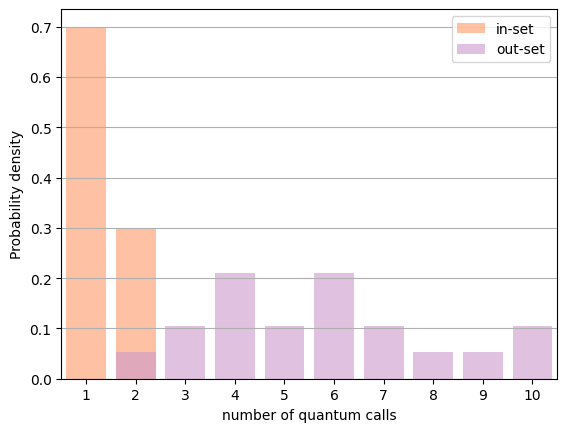

In [5]:
## the same figure as above but including the histogram when we leverage the information of separate components 

import matplotlib.pyplot as plt 
import json 
from collections import Counter 
import os 


numshots=20
problem="atoms_BMW2023_HP1435" 


### inset 
criteria="inset"
directory_path=f"raw_results/qReduMIS/qReduMIS_table_hardware/{criteria}"
sols_inset=[]
c_shots_inset=[]

for cshot in range(numshots):
    with open(f"{directory_path}/{problem}_componentsFalse_results_qReduMIS_cshot{cshot}.json", "r") as infile:
        res = json.load(infile)
    num_its=res['final']['num iterations']
    sol=len(res['final']['sol'])


    sols_inset.append(sol)
    c_shots_inset.append(num_its)

data = (sols_inset,)

true_mis=baseline[problem]
stat=a_stat(true_mis, len(sols_inset))
res_boot = bootstrap(data, stat, confidence_level=0.9)

print("---------")
print(f"problem {problem} for qReduMIS with criteria {criteria}: PMIS= ", np.round(np.mean(res_boot.bootstrap_distribution),3),  np.round(np.std(res_boot.bootstrap_distribution),3))


counter_c_shots_inset=Counter(c_shots_inset)
values_c_shots_inset = list(counter_c_shots_inset.values())
total_c_shots_inset = sum(values_c_shots_inset)
probabilities_c_shots_inset = [val / total_c_shots_inset for val in values_c_shots_inset]

#----
criteria="outset"
directory_path=f"raw_results/qReduMIS/qReduMIS_table_hardware/{criteria}"
sols_outset=[]
c_shots_outset=[]
for cshot in range(numshots):
    with open(f"{directory_path}/{problem}_componentsFalse_results_qReduMIS_cshot{cshot}.json", "r") as infile:
        res = json.load(infile)
    if 'final' in res.keys():
        num_its=res['final']['num iterations']
        sol=len(res['final']['sol'])


        sols_outset.append(sol)
        c_shots_outset.append(num_its)

counter_c_shots_outset=Counter(c_shots_outset)
values_c_shots_outset = list(counter_c_shots_outset.values())
total_c_shots_outset = sum(values_c_shots_outset)
probabilities_c_shots_outset= [val / total_c_shots_outset for val in values_c_shots_outset]

data = (sols_outset,)

true_mis=baseline[problem]
stat=a_stat(true_mis, len(sols_outset))
res_boot = bootstrap(data, stat, confidence_level=0.9)

print("---------")
print(f"problem {problem} for qReduMIS with criteria {criteria}: PMIS= ", np.round(np.mean(res_boot.bootstrap_distribution),3),  np.round(np.std(res_boot.bootstrap_distribution),3))


# Plot the distribution_quantum_calls_
fig, ax = plt.subplots()
colors = [(1.0, 0.6, 0.4, 0.7),  # Pastel orange with transparency
          (0.8, 0.6, 0.8, 0.7) ]  # Pastel green with transparency

plt.bar(counter_c_shots_inset.keys(), probabilities_c_shots_inset, color=colors[0],  alpha=0.6, label="in-set")
plt.bar(counter_c_shots_outset.keys(), probabilities_c_shots_outset, color=colors[1],  alpha=0.6, label="out-set")
plt.xlabel("number of quantum calls")
plt.ylabel("Probability density")
plt.xticks([1,2, 3,4,5,6,7,8,9,10])
plt.xlim([0.5, 10.5])
#plt.title(f"{criteria} criteria to inform")
plt.grid(axis='y')
plt.legend()




#plt.legend()
#plt.savefig(f'distribution_quantum_calls_{problem}_HW.png', dpi=300, bbox_inches='tight', transparent=False)

plt.show()